# Unbalanced Optimal Transport

Classical transport enforces exact mass conservation.  
Unbalanced OT relaxes this by penalizing marginal mismatch, which is essential when sources and targets have different total mass.

A common entropic-KL model is:
$$
\min_{\gamma \ge 0}\ \langle C,\gamma \rangle + \varepsilon \mathrm{KL}(\gamma\|\mathbf{1})
 + \tau\mathrm{KL}(\gamma\mathbf{1}\|a) + \tau\mathrm{KL}(\gamma^\top\mathbf{1}\|b).
$$

Unbalanced optimal transport relaxes exact marginal constraints by penalizing mass creation and destruction, often with a Kullback--Leibler divergence. Varying the mass penalty interpolates between local deletion and nearly balanced displacement, revealing when transport is cheaper than changing mass.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/unbalanced-ot") if Path("python/unbalanced-ot").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Data and transport kernel

We use two 1D non-normalized measures with different total masses, then compare solutions for several balancing strengths $\tau$.


In [2]:
n = 220
x = np.linspace(0, 1, n)

a = 1.2*np.exp(-((x-0.22)/0.07)**2) + 0.6*np.exp(-((x-0.42)/0.04)**2)
b = 0.9*np.exp(-((x-0.64)/0.06)**2) + 0.3*np.exp(-((x-0.84)/0.03)**2)
a = np.maximum(a, 1e-12)
b = np.maximum(b, 1e-12)
C = (x[:, None]-x[None, :])**2
eps = 0.008
K = np.exp(-C/eps)


## Generalized Sinkhorn iterations

For KL-penalized marginals, updates become power-scalings:
$$
u \leftarrow \left(\frac{a}{Kv}\right)^\theta,\qquad
v \leftarrow \left(\frac{b}{K^\top u}\right)^\theta,\qquad
\theta=\frac{\tau}{\tau+\varepsilon}.
$$
Smaller $\tau$ allows stronger mass creation/destruction.


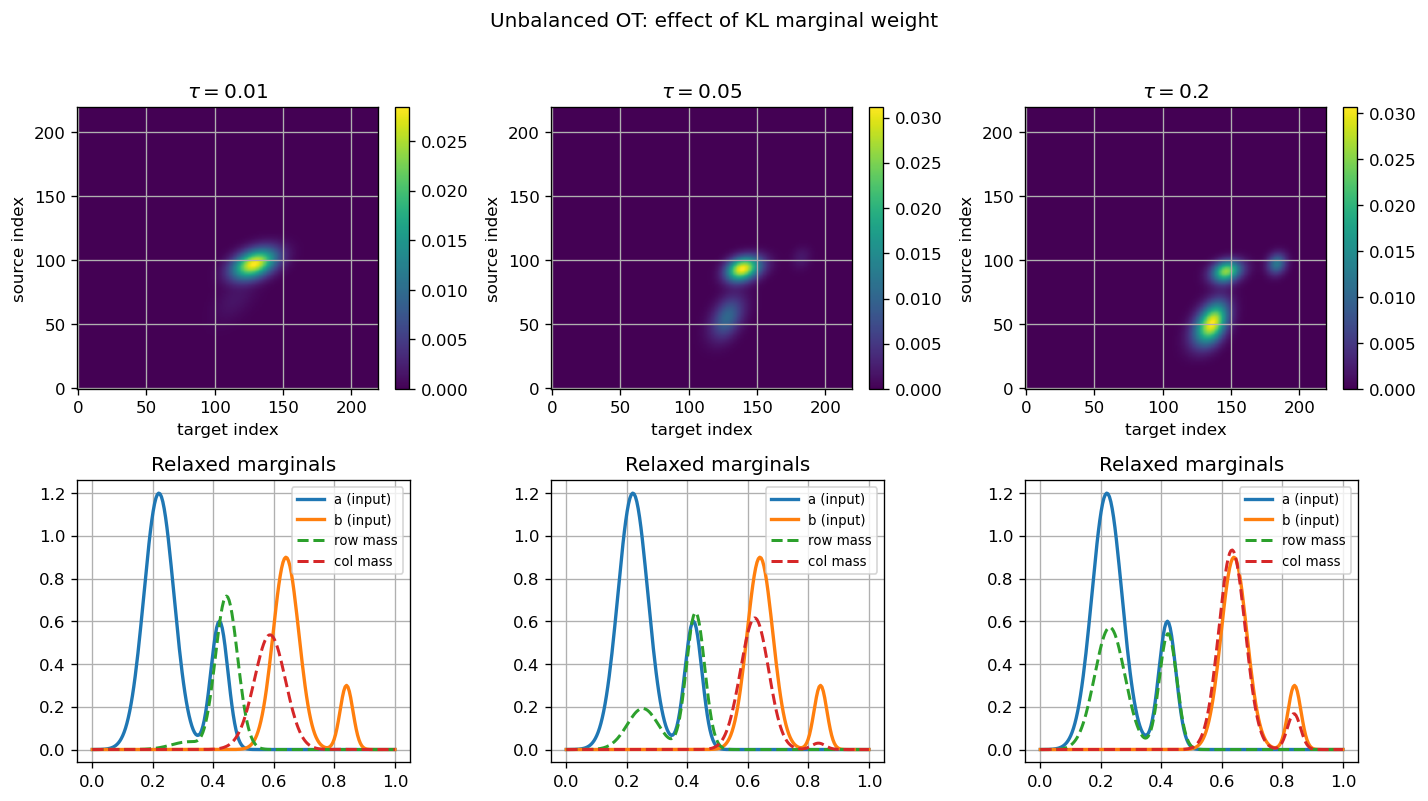

In [3]:
def unbalanced_sinkhorn(a, b, K, eps, tau, n_iter=700):
    theta = tau / (tau + eps)
    u = np.ones_like(a)
    v = np.ones_like(b)
    for _ in range(n_iter):
        u = (a / (K @ v + 1e-16))**theta
        v = (b / (K.T @ u + 1e-16))**theta
    G = (u[:, None] * K) * v[None, :]
    return G

taus = [0.01, 0.05, 0.2]
Gs = [unbalanced_sinkhorn(a, b, K, eps, tau=t) for t in taus]

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
for j, (tau, G) in enumerate(zip(taus, Gs)):
    im = axes[0, j].imshow(G, origin="lower", cmap="viridis", aspect="auto")
    axes[0, j].set_title(fr"$\tau={tau}$")
    axes[0, j].set_xlabel("target index")
    axes[0, j].set_ylabel("source index")
    fig.colorbar(im, ax=axes[0, j], fraction=0.046)

    axes[1, j].plot(x, a, lw=2, label="a (input)")
    axes[1, j].plot(x, b, lw=2, label="b (input)")
    axes[1, j].plot(x, G.sum(axis=1), "--", lw=1.8, label="row mass")
    axes[1, j].plot(x, G.sum(axis=0), "--", lw=1.8, label="col mass")
    axes[1, j].set_title("Relaxed marginals")
    axes[1, j].legend(fontsize=8)

fig.suptitle("Unbalanced OT: effect of KL marginal weight", y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- L. Chizat, G. Peyré, B. Schmitzer, F.-X. Vialard, "Scaling Algorithms for Unbalanced Transport Problems", Math. Comp., 2018.
- L. Chizat, G. Peyré, B. Schmitzer, F.-X. Vialard, "Unbalanced Optimal Transport: Dynamic and Kantorovich Formulations", JFA, 2018.
- G. Peyré, M. Cuturi, *Computational Optimal Transport*, Foundations and Trends in ML, 2019.
